In [175]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
import pickle

import pandas as pd
import time
import os
import sys
import zarr
import napari 
import dask.array as da 

from skimage import exposure
import matplotlib.pyplot as plt
#from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patches as mpatches
from scipy.spatial import cKDTree

pythonPackagePath = os.path.abspath('/Users/valerie/LLSM-CME-ANALYSIS/Final/src')
sys.path.append(pythonPackagePath)
# from parallel import Detector
from gaussian_visualization import visualize_3D_gaussians

In [191]:
channel_to_detect = 3

# Define the file directories (change these to reflect your directories)
base_dir =  r'/Volumes/ActiveNAS/Valerie/TransferFolder/'
input_file_directory = '20251204_DetectionTesting/lumenoids_analysis/'
zarr_file_directory = input_file_directory + 'zarr_file/all_channels_data'

zarr_full_path = os.path.join(base_dir, zarr_file_directory)

print('Zarr file path:', zarr_full_path)

Zarr file path: /Volumes/ActiveNAS/Valerie/TransferFolder/20251204_DetectionTesting/lumenoids_analysis/zarr_file/all_channels_data


In [192]:
z2 = zarr.open(zarr_full_path, mode='r') 

In [193]:
# Load the detections
# path_to_detections = os.path.join(base_dir, input_file_directory) + 'output/uTrack3DPackage/detect3D/channel_3.mat'
path_to_detections = os.path.join(base_dir, input_file_directory) + 'detection/channel_1.mat'
# path_to_detections = os.path.join(base_dir, input_file_directory) + 'detection_results/channel_1.mat'

detections_dict = loadmat(path_to_detections)

/Users/valerie/anaconda3/envs/cme_pipeline/lib/python3.10/site-packages/scipy/io/matlab/_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab._mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [194]:
# Get the key for your detections
key = 'movieInfo'  # Replace with your actual key name
detection_data = detections_dict[key]

# Create an empty list to store all detections
all_detections = []

# Helper function to safely extract array data
def extract_array(field):
    """Extract data from potentially nested arrays"""
    if field.size == 0:
        return np.array([])
    
    # Handle different possible structures
    if field.dtype.names is not None:
        field = field[0]
    
    if isinstance(field, np.ndarray) and field.size == 1:
        field = field[0]
        
    return field

# Loop through each frame
for frame_idx in range(detection_data.shape[0]):
    try:
        # Get current frame data
        frame_data = detection_data[frame_idx, 0]
        
        # Skip frames with no detections
        if frame_data.size == 0 or 'xCoord' not in frame_data.dtype.names:
            print(f"Skipping frame {frame_idx} due to missing data")
            continue
            
        # Extract arrays for each field
        x_coords = extract_array(frame_data['xCoord'])
        y_coords = extract_array(frame_data['yCoord'])
        z_coords = extract_array(frame_data['zCoord'])
        amp_vals = extract_array(frame_data['amp'])
        int_vals = extract_array(frame_data['int'])

       
        
        # Skip if any arrays are empty
        if any(arr.size == 0 for arr in [x_coords, y_coords, z_coords, amp_vals, int_vals]):
            print(f"Skipping frame {frame_idx} due to empty detection arrays")
            continue
            
        # Determine number of detections in this frame
        num_detections = x_coords.shape[0]

        # Go through num_detections and print if any of x_coords[i][0] is NaN
        for i in range(num_detections):
            if np.isnan(x_coords[i][0]) or np.isnan(y_coords[i][0]) or np.isnan(z_coords[i][0]):
                print(f"Frame {frame_idx}, Detection {i}: NaN value found in coordinates")
                


        # For each detection in this frame
        for i in range(num_detections):
                
                # Skip detection if any value is NaN
                if np.isnan(x_coords[i][0]) or np.isnan(y_coords[i][0]) or np.isnan(z_coords[i][0]):
                    continue

                # mu_x = round(x_coords[i][0]) if len(x_coords[i]) > 0 else np.nan
                # mu_y = round(y_coords[i][0]) if len(y_coords[i]) > 0 else np.nan
                # mu_z = round(z_coords[i][0]) if len(z_coords[i]) > 0 else np.nan
                # amplitude = round(amp_vals[i][0]) if len(amp_vals[i]) > 0 else np.nan
                # intensity = round(int_vals[i][0]) if len(int_vals[i]) > 0 else np.nan

                # detection = {
                #     'frame': frame_idx,  # 1-based frame indexing
                #     'mu_x': mu_x,
                #     'mu_y': mu_y,
                #     'mu_z': mu_z,
                #     'amplitude': amplitude,
                #     'intensity': intensity,
                # }
                detection = {
                    'frame': frame_idx,  # 1-based frame indexing
                    'mu_x': (x_coords[i][0]) if len(x_coords[i]) > 0 else np.nan,
                    'mu_y': (y_coords[i][0]) if len(y_coords[i]) > 0 else np.nan,
                    'mu_z': (z_coords[i][0]) if len(z_coords[i]) > 0 else np.nan,
                    'amplitude': (amp_vals[i][0]) if len(amp_vals[i]) > 0 else np.nan, # Returning a background corrected background
                    'intensity': (int_vals[i][0]) if len(int_vals[i]) > 0 else np.nan,
                }

            
            
            # Add confidence values if available
                if len(x_coords[i]) > 1:
                    detection.update({
                        'x_conf': x_coords[i][1],
                        'y_conf': y_coords[i][1],
                        'z_conf': z_coords[i][1],
                        'amp_conf': amp_vals[i][1],
                        'int_conf': int_vals[i][1],
                    })
                    
                all_detections.append(detection)
    except Exception as e:
        print(f"Error processing frame {frame_idx}: {e}")
        continue

# Create DataFrame from all detections
df = pd.DataFrame(all_detections).set_index('frame')

# Add 3 columns, sigma_x, sigma_y, and sigma_z, such that sigma_x = sigma_y = 2, and sigma_z = 3
df['sigma_x'] = 2
df['sigma_y'] = 2
df['sigma_z'] = 3

# Print summary
if not df.empty:
    print(f"Created DataFrame with {len(df)} total detections across {df.reset_index()['frame'].nunique()} frames")
else:
    print("No detections were found in the data")

Created DataFrame with 55717 total detections across 150 frames


In [195]:
# # Save df in path_to_detections as a pickle file
output_path = path_to_detections.replace('.mat', '3_detections.pkl')
df.to_pickle(output_path)
print(f"Saved detections DataFrame to {output_path}")

Saved detections DataFrame to /Volumes/ActiveNAS/Valerie/TransferFolder/20251204_DetectionTesting/lumenoids_analysis/detection/channel_13_detections.pkl


In [ ]:
# If detections have previously been saved, can run this block to load them
# After running the first three blocks
# path_to_detections = os.path.join(base_dir, input_file_directory) + 'detection/channel_1_detections.pkl'
# df = pd.read_pickle(path_to_detections).reset_index()

In [196]:
# Visualizing the detections in Napari

# Make a mask of the first time point of the detections

df_reset = df.reset_index()

masks = visualize_3D_gaussians(zarr_obj = z2, gaussians_df = df_reset[df_reset['frame'] == 0])
# masks = visualize_3D_gaussians(zarr_obj = z2, gaussians_df = df)

# Create a napari viewer
viewer = napari.Viewer()

#open the zarr file in read mode
dask_array = da.from_zarr(z2)

# first time point of the zarr file and the channel to detect
#the axis arrangement is (t,c,z,y,x)

# dask_array_slice = dask_array[48,channel_to_detect-1,:,:,:]
dask_array_slice = dask_array[0,2,:,:,:]

# Add the 3D stack to the viewer
layer_raw = viewer.add_image(dask_array_slice, name='fluorescence', interpolation3d = 'nearest', blending = 'additive', colormap = 'magenta')

# dask_array_slice = dask_array[48,channel_to_detect-1,:,:,:]
dask_array_slice = dask_array[0,1,:,:,:]

# Add the 3D stack to the viewer
layer_raw = viewer.add_image(dask_array_slice, name='fluorescence', interpolation3d = 'nearest', blending = 'additive', colormap = 'cyan')

# layer_mask = viewer.add_image(masks, name = 'detections mask')
layer_mask = viewer.add_image(masks, name = 'detections', interpolation3d = 'nearest', blending = 'additive', colormap = 'green')

#other useful parameters 
#color_map = list
#contrast_limits = list of list 

# Add Bounding Box
layer_raw.bounding_box.visible = True

In [197]:
df_reset.head() 

,frame,mu_x,mu_y,mu_z,amplitude,intensity,x_conf,y_conf,z_conf,amp_conf,int_conf,sigma_x,sigma_y,sigma_z
0,0,101.029513,243.400194,8.183556,45.197302,45.197302,0.119545,0.119535,0.170884,2.925542,2.925542,2,2,3
1,0,76.761048,168.225046,9.448784,28.797479,28.797479,0.140039,0.140039,0.200274,2.183025,2.183025,2,2,3
2,0,76.630535,208.269008,9.482729,60.459012,60.459012,0.091675,0.091675,0.131117,3.000204,3.000204,2,2,3
3,0,72.159576,192.243008,10.736624,50.746429,50.746429,0.107895,0.107895,0.154448,2.962956,2.962956,2,2,3
4,0,102.097443,113.409880,10.433521,48.315834,48.315834,0.088205,0.088205,0.126141,2.306980,2.306980,2,2,3


In [198]:
# Filter for spots in the first frame only
first_frame_spots = df_reset[df_reset['frame'] == 0]

# # Extract coordinates (z, y, x format for napari)
# spots_coords = first_frame_spots[['mu_z', 'mu_y', 'mu_x']].values

# # Generate random colors for each point (RGB values between 0 and 1)
# n_points = len(spots_coords)
# random_colors = np.random.rand(n_points, 3)  # Shape: (n_points, 3) for RGB

# Add to napari viewer
# viewer.add_points(spots_coords, 
#                   name='First Frame Spots',
#                   size=3,  # Adjust size as needed
#                   face_color='random_colors',  # Change color as desired
#                   # edge_color='white'
#                   )

# Extract coordinates (z, y, x format for napari)
spots_coords = first_frame_spots[['mu_z', 'mu_y', 'mu_x']].values

# Generate random colors for each point (RGB values between 0 and 1)
n_points = len(spots_coords)
random_colors = np.random.rand(n_points, 3)  # Shape: (n_points, 3) for RGB

# Add to napari viewer
viewer.add_points(spots_coords, 
                  name='First Frame Spots',
                  size=2,
                  face_color=random_colors,
                  # edge_color='white'
                  )

<Points layer 'First Frame Spots' at 0x7fd088a56e60>

In [ ]:
### ALPHA TESTING VISUALIZATION ###

#Import three different existing pkl files from /Volumes/ActiveNAS/Valerie/TransferFolder/20251204_DetectionTesting/lumenoids_analysis/alphatests/channel_1_ch3_alpha1_detections.pkl
# df_AP2 = pd.read_pickle(os.path.join(base_dir, input_file_directory) + 'alphatests/channel_1_ch3_alpha2_detections.pkl').reset_index()
# df_DNM = pd.read_pickle(os.path.join(base_dir, input_file_directory) + 'alphatests/channel_1_ch2_alpha2_detections.pkl').reset_index()
# viewer.add_points(df_AP2[df_AP2['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='blue',size=2, name='AP2')
# viewer.add_points(df_DNM[df_DNM['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='red',size=2, name='DNM')

#Import three different existing pkl files from /Volumes/ActiveNAS/Valerie/TransferFolder/20251204_DetectionTesting/lumenoids_analysis/alphatests/channel_1_ch3_alpha1_detections.pkl
# df_alpha1 = pd.read_pickle(os.path.join(base_dir, input_file_directory) + 'alphatests/channel_1_ch1_alpha1_detections.pkl').reset_index()
# df_alpha2 = pd.read_pickle(os.path.join(base_dir, input_file_directory) + 'alphatests/channel_1_ch1_alpha2_detections.pkl').reset_index()
#df_alpha3 = pd.read_pickle(os.path.join(base_dir, input_file_directory) + 'alphatests/channel_1_ch2_alpha3_detections.pkl').reset_index()

#print the size of each dataframe
# print(f"Condition 1 detections: {len(df_alpha1)}")
# print(f"Condition 2 detections: {len(df_alpha2)}")
#print(f"Condition 3 detections: {len(df_alpha3)}")

#Add then first frame spots from df1, df2, and df3 to the napari viewer with different colors
# viewer.add_points(df_alpha1[df_alpha1['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='yellow',size=2, name='alpha = 0.01')
# viewer.add_points(df_alpha2[df_alpha2['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='cyan',size=2, name = 'alpha = 0.05')
#viewer.add_points(df_alpha3[df_alpha3['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='green',size=2, name = 'alpha = 0.001')


In [121]:
#Compare the detection coordinates from df1, df2, and df3 and create a new dataframe with the detections that don't overlap
def get_non_overlapping_detections(df_main, df_compare_list, threshold=3.0):
    """
    Identify detections in df_main that do not overlap with any detections in df_compare_list.
    
    Parameters:
    - df_main: DataFrame containing the main detections to check.
    - df_compare_list: List of DataFrames to compare against.
    - threshold: Distance threshold to consider detections as overlapping.
    
    Returns:
    - DataFrame of non-overlapping detections from df_main.
    """
    # Create a KDTree for each comparison DataFrame
    trees = [cKDTree(df[['mu_x', 'mu_y', 'mu_z']].values) for df in df_compare_list]
    
    non_overlapping_indices = []
    
    for idx, row in df_main.iterrows():
        point = row[['mu_x', 'mu_y', 'mu_z']].values
        is_overlapping = False
        
        # Check against each tree
        for tree in trees:
            distances, _ = tree.query(point, k=1)
            if distances < threshold:
                is_overlapping = True
                break
        
        if not is_overlapping:
            non_overlapping_indices.append(idx)
    
    return df_main.loc[non_overlapping_indices]

In [172]:
#add unique detections from frame 0 as spots in napari viewer
non_overlapping_df1 = get_non_overlapping_detections(df_alpha1, [df_alpha2, df_alpha2], threshold=3.0)
non_overlapping_df2 = get_non_overlapping_detections(df_alpha2, [df_alpha1, df_alpha1], threshold=3.0)
#non_overlapping_df3 = get_non_overlapping_detections(df_alpha3, [df_alpha1, df_alpha2], threshold=3.0)
viewer.add_points(non_overlapping_df1[non_overlapping_df1['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='green', size=1, name='alpha = 0.01 unique')
viewer.add_points(non_overlapping_df2[non_overlapping_df2['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='magenta', size=1, name='alpha = 0.05 unique')
#viewer.add_points(non_overlapping_df3[non_overlapping_df3['frame'] == 0][['mu_z', 'mu_y', 'mu_x']].values, face_color='yellow', size=1, name='alpha = 0.001 unique')

<Points layer 'alpha = 0.05 unique' at 0x7fd0ec0280d0>

In [173]:
#print the number of non-overlapping detections
print(f"Condition 1 non-overlapping detections: {len(non_overlapping_df1)}")
print(f"Condition 2 non-overlapping detections: {len(non_overlapping_df2)}")
#print(f"Condition 3 non-overlapping detections: {len(non_overlapping_df3)}")

Condition 1 non-overlapping detections: 2
Condition 2 non-overlapping detections: 208


In [174]:
#Save the non-overlapping detections to new pkl files
non_overlapping_df1.to_pickle(r'/Volumes/ActiveNAS/Valerie/TransferFolder/20251204_DetectionTesting/lumenoids_analysis/alphatests/ArpC3_alpha1_non_overlapping.pkl')
non_overlapping_df2.to_pickle(r'/Volumes/ActiveNAS/Valerie/TransferFolder/20251204_DetectionTesting/lumenoids_analysis/alphatests/ArpC3_alpha2_non_overlapping.pkl')
#non_overlapping_df3.to_pickle(r'/Volumes/ActiveNAS/Valerie/TransferFolder/20251204_DetectionTesting/lumenoids_analysis/alphatests/DNM_alpha3_non_overlapping.pkl')

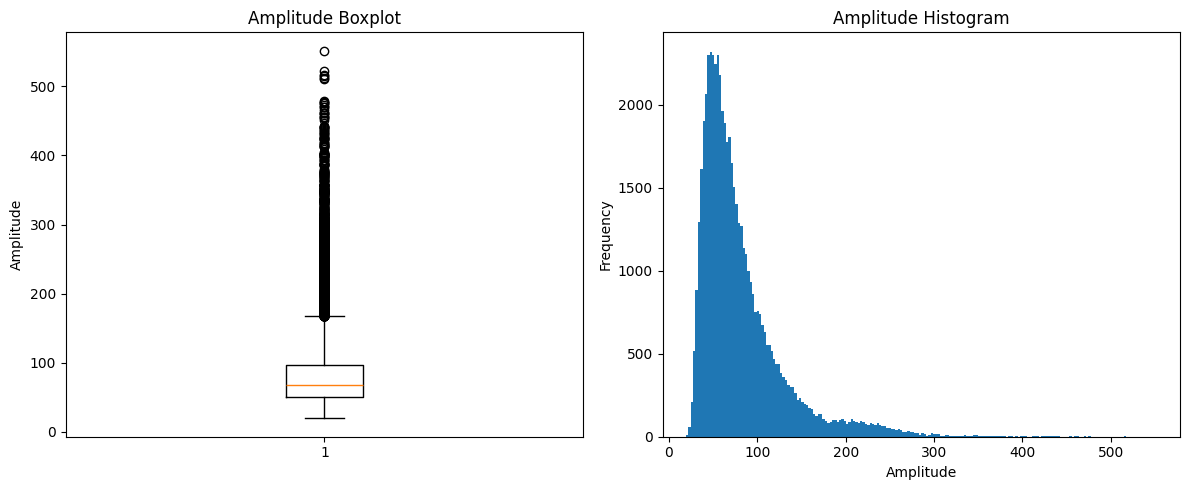

In [79]:
# Plot the distribution of 'amplitudes' in the dataframe
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

#First plot: Boxplot of 'amplitude'
axes[0].boxplot(df['amplitude'])
axes[0].set_title('Amplitude Boxplot')
axes[0].set_ylabel('Amplitude')

# Plot histogram of the column 'amplitude' in the dataframe
axes[1].hist(df['amplitude'], bins=200)
axes[1].set_title('Amplitude Histogram')
axes[1].set_xlabel('Amplitude')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [10]:
# Save df to csv on Desktop and load df as a pandas dataframe
# df.to_csv(r'C:\Users\Lab admin\Desktop\detections.csv')
# df_compare = pd.read_csv(r'C:\Users\Lab admin\Desktop\detections.csv')

In [11]:
# df_compare = pd.read_pickle(r'C:\Users\Lab admin\Desktop\u-Track3D\testTrackability/OS_41_5-10min-01_processed-cropped_channel3_analysis/detection_results/channel_1_detections.pkl')